# XGBoost Model

In [7]:
# importing packages
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import xgboost as xgb


Reading in the data sat and creating testing and training data

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


file_path = "C:/Users/cscur/OneDrive/STATSM148/statM148proj-main/truncated_data_codex.parquet"

df_simple = (
    pl.scan_parquet(file_path)
    .drop(['id', 'cutoff_time',
            'journey_terminal_time',
         'journey_terminal_reason'])
    .drop_nulls()  # Polars equivalent of .dropna()
    .collect()     # This triggers the actual calculation
)

cols = df_simple.columns
words = ['seen', 'count']
df_simple = df_simple.drop([col for col in cols if any(w in col for w in words)])

cols = df_simple.columns
words = ['seen', 'count', 'cutoff']
df_simple = df_simple.drop([col for col in cols if any(w in col for w in words)])

# 1. Prepare Features and Target
# one-hot encode 'last_stage' cat variable
df_ml = df_simple.to_dummies(["last_stage",'first_stage']).drop(['first_event_name', 'last_event_name'])

# Define target (y) and features (X)
y = df_ml["label_order_shipped"].to_numpy() # TARGET: Label_order_shipped 

X = df_ml.drop(["label_order_shipped",'first_stage_Downpayment',
                'first_stage_Order Shipped', 'last_stage_Order Shipped']) # FEATURES: all other cols

feature_names = df_ml.drop(["label_order_shipped",'first_stage_Downpayment',
                'first_stage_Order Shipped', 'last_stage_Order Shipped']).columns

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

#print(X_train.columns)
weights = X_train['sampling_weight_days'] 
X_train = X_train.drop(columns = ['sampling_weight_days'])
X_test = X_test.drop(columns = ['sampling_weight_days'])
feature_names = feature_names.remove('sampling_weight_days')

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

Creating and fitting an XGBoost Model

In [4]:
model = xgb.XGBClassifier(
    objective="binary:logistic",  # outputs probabilities
    n_estimators=700,
    max_depth=6,
    learning_rate=0.09,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds = 10
)

#print(xgb.__version__)

model.fit(X_train, y_train,
          eval_set = [(X_test, y_test)],
          verbose = False,
          sample_weight = weights)

probability = model.predict_proba(X_test)[:,1]
y_pred = (probability >= 0.9).astype(int)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

names = model.get_booster().feature_names
print(names)

0.835662204810099
['n_events_observed', 'n_unique_event_types_observed', 'observed_duration_days', 'days_since_last_event', 'first_ed_id', 'first_stage_Apply for Credit', 'first_stage_Credit Account', 'first_stage_Discover', 'first_stage_First Purchase', 'first_stage_Prospecting', 'last_ed_id', 'last_stage_Apply for Credit', 'last_stage_Credit Account', 'last_stage_Discover', 'last_stage_Downpayment', 'last_stage_First Purchase', 'last_stage_Prospecting']


Ranking Most Important Features 

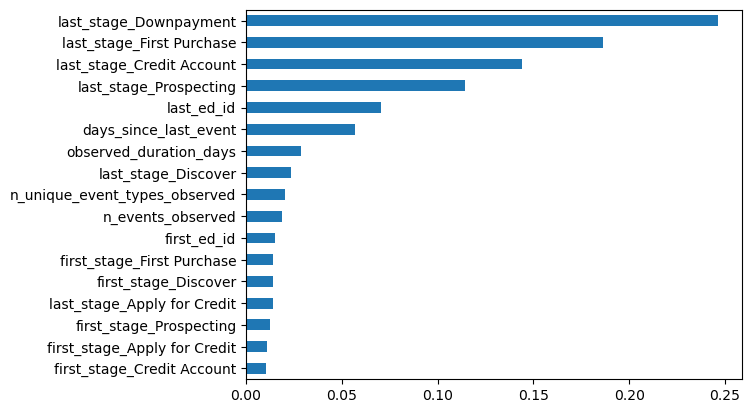

last_stage_Downpayment           0.246558
last_stage_First Purchase        0.186418
last_stage_Credit Account        0.143899
last_stage_Prospecting           0.114045
last_ed_id                       0.070397
days_since_last_event            0.056881
observed_duration_days           0.028556
last_stage_Discover              0.023405
n_unique_event_types_observed    0.020537
n_events_observed                0.018549
first_ed_id                      0.014881
first_stage_First Purchase       0.014111
first_stage_Discover             0.014012
last_stage_Apply for Credit      0.013860
first_stage_Prospecting          0.012679
first_stage_Apply for Credit     0.010896
first_stage_Credit Account       0.010316
dtype: float32


In [11]:
importance = pd.Series(model.feature_importances_, index = names)
importance = importance.sort_values(ascending = False)

importance.plot(kind = 'barh')
plt.gca().invert_yaxis()
plt.show()
print(importance)

Reading in test data and restructuring it

In [39]:
test_path = "C:/Users/cscur/OneDrive/STATSM148/statM148proj-main/truncated_test_data.parquet"

test_data = pl.read_parquet(test_path)

df_test = (
    pl.scan_parquet(test_path)
    #.select(essential_cols)
    .drop(['id', 'cutoff_time', 'journey_terminal_time',
            'journey_terminal_reason', 'sampling_weight_days'])
      # Polars equivalent of .dropna()
    .collect()     # This triggers the actual calculation
)
print(df_test.shape)
cols = df_test.columns

print(feature_names)
words = ['seen', 'count','cutoff']
df_test = df_test.drop([col for col in cols if any(w in col for w in words)])

# 1. Prepare Features and Target
# one-hot encode 'last_stage' cat variable
df_ml_test = df_test.to_dummies(["last_stage",'first_stage']).drop(['first_event_name', 'last_event_name'])
print(df_ml_test.columns)
print(names)
# Define target (y) and features (X)
y_test_true = df_ml_test["label_order_shipped"].to_numpy() # TARGET: Label_order_shipped 
X_test_true = df_ml_test.drop(["label_order_shipped",'first_stage_null','last_stage_null']) # FEATURES: all other cols



probability_test = model.predict_proba(X_test_true)[:,1]
print(probability_test)
y_pred_true = (probability_test >= 0.8).astype(int)


(158325, 72)
None
['label_order_shipped', 'n_events_observed', 'n_unique_event_types_observed', 'observed_duration_days', 'days_since_last_event', 'first_ed_id', 'first_stage_Apply for Credit', 'first_stage_Credit Account', 'first_stage_Discover', 'first_stage_First Purchase', 'first_stage_Prospecting', 'first_stage_null', 'last_ed_id', 'last_stage_Apply for Credit', 'last_stage_Credit Account', 'last_stage_Discover', 'last_stage_Downpayment', 'last_stage_First Purchase', 'last_stage_Prospecting', 'last_stage_null']
['n_events_observed', 'n_unique_event_types_observed', 'observed_duration_days', 'days_since_last_event', 'first_ed_id', 'first_stage_Apply for Credit', 'first_stage_Credit Account', 'first_stage_Discover', 'first_stage_First Purchase', 'first_stage_Prospecting', 'last_ed_id', 'last_stage_Apply for Credit', 'last_stage_Credit Account', 'last_stage_Discover', 'last_stage_Downpayment', 'last_stage_First Purchase', 'last_stage_Prospecting']
[0.07719346 0.11869498 0.0308233  ..

Creating a csv for submission

In [40]:
ids =pl.scan_parquet(test_path).select(['id']).collect()
pred_matrix = np.column_stack((ids, y_pred_true))
pred_df = pd.DataFrame(pred_matrix, columns = ['id','order_shipped'])
pred_df.to_csv('submission_1.csv', index = False)

# Hyperparameter Tuning
1. Learning Rate and Number of Trees

In [7]:
rates = np.arange(0.1,0.01, -0.01)
ntrees = np.arange(100, 1000, 100)

scores = np.empty((100,3))

count = 0
for i in ntrees:
    
    for j in rates:
        
        scores[count,0] = i
        scores[count,1] = j

        model = xgb.XGBClassifier(
            objective="binary:logistic",  # outputs probabilities
            n_estimators=i,
            max_depth=6,
            learning_rate=j,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            early_stopping_rounds = 10

        )
    
        model.fit(X_train, y_train,
          eval_set = [(X_test, y_test)],
          verbose = False)

        probability = model.predict_proba(X_test)[:,1]
        y_pred = (probability >= 0.9).astype(int)
        from sklearn.metrics import accuracy_score
        score = accuracy_score(y_test, y_pred)
        scores[count,2]  = score

        count += 1



[0]	validation_0-logloss:0.46815
[1]	validation_0-logloss:0.41511
[2]	validation_0-logloss:0.37294
[3]	validation_0-logloss:0.35131
[4]	validation_0-logloss:0.32218
[5]	validation_0-logloss:0.29772
[6]	validation_0-logloss:0.28347
[7]	validation_0-logloss:0.26366
[8]	validation_0-logloss:0.25428
[9]	validation_0-logloss:0.23908
[10]	validation_0-logloss:0.22520
[11]	validation_0-logloss:0.21331
[12]	validation_0-logloss:0.20286
[13]	validation_0-logloss:0.19734
[14]	validation_0-logloss:0.18848
[15]	validation_0-logloss:0.18080
[16]	validation_0-logloss:0.17694
[17]	validation_0-logloss:0.17359
[18]	validation_0-logloss:0.16756
[19]	validation_0-logloss:0.16205
[20]	validation_0-logloss:0.15722
[21]	validation_0-logloss:0.15273
[22]	validation_0-logloss:0.14867
[23]	validation_0-logloss:0.14515
[24]	validation_0-logloss:0.14204
[25]	validation_0-logloss:0.13926
[26]	validation_0-logloss:0.13801
[27]	validation_0-logloss:0.13560
[28]	validation_0-logloss:0.13341
[29]	validation_0-loglos

In [9]:
score_df = pd.DataFrame(scores, 
                        columns = ['n_trees', 'learning_speed', 'accuracy']).sort_values(by = 'accuracy', ascending = False)
score_df


,n_trees,learning_speed,accuracy
55,7.000000e+02,9.000000e-02,9.673087e-01
73,9.000000e+02,9.000000e-02,9.673087e-01
64,8.000000e+02,9.000000e-02,9.673087e-01
46,6.000000e+02,9.000000e-02,9.672108e-01
36,5.000000e+02,1.000000e-01,9.668734e-01
...,...,...,...
88,0.000000e+00,0.000000e+00,0.000000e+00
87,0.000000e+00,0.000000e+00,0.000000e+00
93,1.224007e-311,0.000000e+00,0.000000e+00
94,4.243992e-313,1.223933e-311,0.000000e+00


2. Calibrating Probabilities

In [42]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(model, method = 'isotonic')
calibrated_model.fit(X_train, y_train,
                     eval_set = [(X_test, y_test)],
                     verbose = False)
prob_calib= calibrated_model.predict_proba(X_test)[:,1]
y_pred_calib = (prob_calib >= 0.9).astype(int)

accuracy_score(y_test, y_pred_calib)

0.8788551529002068

Predicting Test Data with Calibrated Model

In [ ]:
calib_test = calibrated_model.predict_proba(X_test_true)[:,1]
print(calib_test)
y_calib_true = (calib_test >= 0.8).astype(int)

calib_matrix = np.column_stack((ids, y_calib_true))
calib_df = pd.DataFrame(calib_matrix, columns = ['id','order_shipped'])
calib_df.to_csv('submission_c.csv', index = False)

[0.13826982 0.20879092 0.02410395 ... 0.02737002 0.13616656 0.4406365 ]


: 